<a href="https://colab.research.google.com/github/krzysztofkleczewskikk/repo-1/blob/main/CodingTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pyspark

In [1]:
from pyspark.sql import functions as F, Window
from pyspark.sql import SparkSession


spark = SparkSession.builder \
    .appName("codingtask") \
    .getOrCreate()

customers_df = spark.createDataFrame(
    [
        ("C1", "Alice", "USA"),
        ("C2", "Bob", "USA"),
        ("C3", "Carol", "UK"),
        ("C4", "Dave", "UK"),
        ("C5", "Eve", "Germany"),
    ],
    ["customer_id", "customer_name", "country"],
)

transactions_df = spark.createDataFrame(
    [
        ("T1", "C1", 500, "05/01/2024"),
        ("T2", "C1", 50, "10/01/2024"),
        ("T3", "C2", 300, "07/01/2024"),
        ("T4", "C3", 120, "01/02/2024"),
        ("T5", "C3", 800, "15/02/2024"),
        ("T6", "C4", 60, "20/02/2024"),
        ("T7", "C5", 450, "01/03/2024"),
        ("T8", "C1", 200, "05/03/2024"),
        ("T9", "C2", 90, "10/03/2024"),
    ],
    ["transaction_id", "customer_id", "amount", "transaction_date"],
)

customers_df.show()
transactions_df.show()


+-----------+-------------+-------+
|customer_id|customer_name|country|
+-----------+-------------+-------+
|         C1|        Alice|    USA|
|         C2|          Bob|    USA|
|         C3|        Carol|     UK|
|         C4|         Dave|     UK|
|         C5|          Eve|Germany|
+-----------+-------------+-------+

+--------------+-----------+------+----------------+
|transaction_id|customer_id|amount|transaction_date|
+--------------+-----------+------+----------------+
|            T1|         C1|   500|      05/01/2024|
|            T2|         C1|    50|      10/01/2024|
|            T3|         C2|   300|      07/01/2024|
|            T4|         C3|   120|      01/02/2024|
|            T5|         C3|   800|      15/02/2024|
|            T6|         C4|    60|      20/02/2024|
|            T7|         C5|   450|      01/03/2024|
|            T8|         C1|   200|      05/03/2024|
|            T9|         C2|    90|      10/03/2024|
+--------------+-----------+------+----

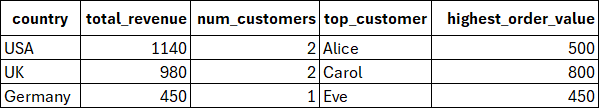

In [16]:
joined_df = transactions_df.join(customers_df, "customer_id", "left")
joined_df.show()

+-----------+--------------+------+----------------+-------------+-------+
|customer_id|transaction_id|amount|transaction_date|customer_name|country|
+-----------+--------------+------+----------------+-------------+-------+
|         C3|            T4|   120|      01/02/2024|        Carol|     UK|
|         C1|            T1|   500|      05/01/2024|        Alice|    USA|
|         C1|            T2|    50|      10/01/2024|        Alice|    USA|
|         C2|            T3|   300|      07/01/2024|          Bob|    USA|
|         C3|            T5|   800|      15/02/2024|        Carol|     UK|
|         C4|            T6|    60|      20/02/2024|         Dave|     UK|
|         C5|            T7|   450|      01/03/2024|          Eve|Germany|
|         C1|            T8|   200|      05/03/2024|        Alice|    USA|
|         C2|            T9|    90|      10/03/2024|          Bob|    USA|
+-----------+--------------+------+----------------+-------------+-------+



In [18]:
from numpy import partition
aggregated_df = joined_df.groupBy(joined_df.country).agg(
                F.sum("amount").alias("total_revenue"),
                F.countDistinct("customer_id").alias("num_customers"),
                ).\
                Window.partitionBy("cauntry").orderBy("amount")
aggregated_df.show()

AssertionError: all exprs should be Column